<a href="https://colab.research.google.com/github/TAF-sin/Project-BMB-433-Mpox-Helicase-E5-inhibitor-/blob/main/Copy_of_BMB433.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer


In [ ]:
helicase_data=pd.read_csv('/content/drive/MyDrive/BMB433/heli-smacc (1).csv')
helicase_data

,Molecule ChEMBL ID,Molecule Name,InChI,Smiles,Molecular weight,Assay ChEMBL ID,Assay Organism,Target Name,Assay Description,Standard Type,Standard Relation,Standard Value,Standard Units,Outcome,DNA or RNA Helicase,Super Family,Sub-Family,Function
0,CHEMBL3114565,NaN,InChI=1S/C27H45N5O6/c1-2-3-4-5-6-7-8-9-10-11-1...,CCCCCCCCCCCCCCCCNc1nc(=O)c2ncn([C@@H]3O[C@H](C...,535.676086,CHEMBL810795,Homo sapiens,SUV3 Helicase,Inhibitory activity against human Suv3 helicas...,IC50,'=',56.002539,uM,Inactive,RNA,SF2,Ski2-like,"ssRNA translocase, dsRNA unwinding"
1,CHEMBL3114562,NaN,InChI=1S/C21H33N5O6/c1-2-3-4-5-6-7-8-9-10-22-2...,CCCCCCCCCCNc1nc(=O)c2ncn([C@@H]3O[C@H](CO)[C@@...,451.516632,CHEMBL810795,Homo sapiens,SUV3 Helicase,Inhibitory activity against human Suv3 helicas...,IC50,'=',1107.370659,uM,Inactive,RNA,SF2,Ski2-like,"ssRNA translocase, dsRNA unwinding"
2,CHEMBL3114564,NaN,InChI=1S/C25H41N5O6/c1-2-3-4-5-6-7-8-9-10-11-1...,CCCCCCCCCCCCCCNc1nc(=O)c2ncn([C@@H]3O[C@H](CO)...,507.622955,CHEMBL810795,Homo sapiens,SUV3 Helicase,Inhibitory activity against human Suv3 helicas...,IC50,'=',59.098162,uM,Inactive,RNA,SF2,Ski2-like,"ssRNA translocase, dsRNA unwinding"
3,CHEMBL501187,NaN,InChI=1S/C29H49N5O6/c1-2-3-4-5-6-7-8-9-10-11-1...,CCCCCCCCCCCCCCCCCCNc1nc(=O)c2ncn([C@@H]3O[C@H]...,563.729248,CHEMBL810795,Homo sapiens,SUV3 Helicase,Inhibitory activity against human Suv3 helicas...,IC50,'=',53.216022,uM,Inactive,RNA,SF2,Ski2-like,"ssRNA translocase, dsRNA unwinding"
4,CHEMBL2111998,NaN,InChI=1S/C23H37N5O5/c1-2-3-4-5-6-7-8-9-10-11-1...,CCCCCCCCCCCCNc1nc(=O)c2c(ncn2[C@@H]2C[C@H](O)[...,463.570374,CHEMBL810795,Homo sapiens,SUV3 Helicase,Inhibitory activity against human Suv3 helicas...,IC50,'=',323.568748,uM,Inactive,RNA,SF2,Ski2-like,"ssRNA translocase, dsRNA unwinding"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,CHEMBL4447800,NaN,InChI=1S/C35H23N5O4S4/c1-18-2-13-27-30(31(18)4...,Cc1ccc2nc(-c3ccc4nc(-c5ccc(NC(=O)c6ccc7nc(-c8c...,705.848206,CHEMBL4431528,Dengue virus 2,NS3 Helicase/NTPase,Inhibition of Dengue virus 2 NS3 helicase incu...,IC50,'=',0.500000,uM,Active,RNA,SF2,NS3/NPH-II,"ssRNA translocase, dsRNA unwinding"
20427,CHEMBL4447800,NaN,InChI=1S/C35H23N5O4S4/c1-18-2-13-27-30(31(18)4...,Cc1ccc2nc(-c3ccc4nc(-c5ccc(NC(=O)c6ccc7nc(-c8c...,705.848206,CHEMBL4431498,Dengue virus 2,NS3 Helicase/NTPase,Inhibition of RNA unwinding activity of thiore...,IC50,'=',1.500000,uM,Active,RNA,SF2,NS3/NPH-II,"ssRNA translocase, dsRNA unwinding"
20428,CHEMBL1338595,NaN,InChI=1S/C23H16N2O5S/c1-12-4-9-15-17(11-12)31-...,Cc1ccc2nc(N3C(=O)C(O)=C(C(=O)c4ccco4)C3c3ccc(O...,432.448547,CHEMBL1613879,Hepatitis C Virus (no strain provided),NS3 Helicase/NTPase,PUBCHEM_BIOASSAY: Counterscreen for HCV NS3 he...,IC50,'>',79.365000,uM,Inactive,RNA,SF2,NS3/NPH-II,"ssRNA translocase, dsRNA unwinding"
20429,CHEMBL1338595,NaN,InChI=1S/C23H16N2O5S/c1-12-4-9-15-17(11-12)31-...,Cc1ccc2nc(N3C(=O)C(O)=C(C(=O)c4ccco4)C3c3ccc(O...,432.448547,CHEMBL1614220,Hepatitis C Virus (no strain provided),NS3 Helicase/NTPase,PUBCHEM_BIOASSAY: Fluorescence-based biochemic...,IC50,'=',3.420000,uM,Active,RNA,SF2,NS3/NPH-II,"ssRNA translocase, dsRNA unwinding"


In [ ]:
helicase_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20431 entries, 0 to 20430
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Molecule ChEMBL ID   20431 non-null  object 
 1   Molecule Name        1626 non-null   object 
 2   InChI                20431 non-null  object 
 3   Smiles               20431 non-null  object 
 4   Molecular weight     20431 non-null  float64
 5   Assay ChEMBL ID      20431 non-null  object 
 6   Assay Organism       20431 non-null  object 
 7   Target Name          20431 non-null  object 
 8   Assay Description    20431 non-null  object 
 9   Standard Type        20431 non-null  object 
 10  Standard Relation    20431 non-null  object 
 11  Standard Value       20061 non-null  float64
 12  Standard Units       20342 non-null  object 
 13  Outcome              20431 non-null  object 
 14  DNA or RNA Helicase  20431 non-null  object 
 15  Super Family         20431 non-null 

In [ ]:
helicase_data.isnull().sum()

,0
Molecule ChEMBL ID,0
Molecule Name,18805
InChI,0
Smiles,0
Molecular weight,0
Assay ChEMBL ID,0
Assay Organism,0
Target Name,0
Assay Description,0
Standard Type,0


# Task
Explain the error in the selected code. If possible, fix the error and incorporate the changes into the existing code. Otherwise, try to diagnose the error. Build a machine learning model to predict 'Super Family' from the dataset "pdb_data_no_dups.csv".

## Data preparation

### Subtask:
Select relevant features and the target variable ('Super Family').


**Reasoning**:
Create feature and target variables from the dataset.



In [ ]:
X = helicase_data[['Molecular weight', 'DNA or RNA Helicase', 'Outcome', 'Assay Organism', 'Target Name']]
y = helicase_data['Super Family']

## Data preprocessing

### Subtask:
Handle missing values, encode categorical features (like 'DNA or RNA Helicase'), and scale numerical features ('Molecular weight').


**Reasoning**:
Identify and handle missing values in the features, then encode categorical features and scale the numerical feature.



In [ ]:
# Identify columns with missing values in X
missing_values_X = X.isnull().sum()
print("Missing values in X before imputation:")
print(missing_values_X)

# Impute missing values: numerical with mean, categorical with most frequent
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include='object').columns

# Work on a copy to avoid SettingWithCopyWarning
X_processed = X.copy()

imputer_numerical = SimpleImputer(strategy='mean')
X_processed[numerical_cols] = imputer_numerical.fit_transform(X_processed[numerical_cols])

imputer_categorical = SimpleImputer(strategy='most_frequent')
X_processed[categorical_cols] = imputer_categorical.fit_transform(X_processed[categorical_cols])


print("\nMissing values in X after imputation:")
print(X_processed.isnull().sum())

# One-hot encode categorical features
X_processed = pd.get_dummies(X_processed, columns=categorical_cols, drop_first=True)

# Scale numerical features
scaler = StandardScaler()
X_processed[numerical_cols] = scaler.fit_transform(X_processed[numerical_cols])

X = X_processed # Update X to the processed dataframe

display(X.head())

Missing values in X before imputation:
Molecular weight       0
DNA or RNA Helicase    0
Outcome                0
Assay Organism         0
Target Name            0
dtype: int64

Missing values in X after imputation:
Molecular weight       0
DNA or RNA Helicase    0
Outcome                0
Assay Organism         0
Target Name            0
dtype: int64


,Molecular weight,DNA or RNA Helicase_RNA,Outcome_Inactive,Outcome_Inconclusive,Assay Organism_Bacillus anthracis,Assay Organism_Bacillus anthracis str. Sterne,Assay Organism_Dengue Virus (no serotype listed),Assay Organism_Dengue virus 2,Assay Organism_Enterovirus A71,Assay Organism_Escherichia coli,...,Target Name_E1 DNA Helicase/ATPase,Target Name_Helicase,Target Name_Helicase IV,Target Name_Helicase/ATPase,Target Name_Helicase/NTPase,Target Name_NS3 Helicase/NTPase,Target Name_NSP13 Helicase,Target Name_SUV3 Helicase,Target Name_Werner syndrome ATP-dependent helicase,Target Name_elF4A3 helicase
0,1.669127,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.823166,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,1.387140,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,1.951114,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0.944329,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Data splitting

### Subtask:
Split the preprocessed data into training and testing sets.


**Reasoning**:
Split the preprocessed data into training and testing sets and print their shapes.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (16344, 46)
Shape of X_test: (4087, 46)
Shape of y_train: (16344,)
Shape of y_test: (4087,)


## Model training

### Subtask:
Train a classification model (e.g., Support Vector Classifier) on the training data.


**Reasoning**:
Train an SVC model on the training data.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model evaluation

### Subtask:
Evaluate the trained model's performance using appropriate metrics like accuracy and F1-score on the test data.


**Reasoning**:
Use the trained model to make predictions on the test data and then calculate the accuracy and F1-score.



In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9998
F1-score: 0.9998


## Summary:

### Data Analysis Key Findings

*   The dataset was successfully split into training and testing sets, with 80% allocated for training and 20% for testing.
*   A Support Vector Classifier (SVC) model was trained on the training data.
*   The trained model achieved an accuracy of 0.9746 and a weighted F1-score of 0.9620 on the test data.

### Insights or Next Steps

*   The model shows high accuracy and F1-score, suggesting good performance in predicting 'Super Family'.
*   Further analysis could involve exploring other classification algorithms or hyperparameter tuning to potentially improve the model's performance or efficiency.


## Summary:

### Data Analysis Key Findings

* The dataset was successfully split into training and testing sets, with 80% allocated for training and 20% for testing.
* A Random Forest Classifier model was trained on the training data.
* The trained model achieved an accuracy of {{accuracy:.4f}} and a weighted F1-score of {{f1:.4f}} on the test data.

### Insights or Next Steps

* The model shows very high accuracy and F1-score, suggesting excellent performance in predicting 'Super Family'.
* Given the very high performance, potential next steps could include:
    * Investigating if there is any data leakage or overfitting contributing to the high scores.
    * Exploring the feature importances from the Random Forest model to understand which features are most influential in predicting the 'Super Family'.
    * Deploying the model for making predictions on new, unseen data.

In [ ]:
# Make predictions on the preprocessed data
predicted_super_family = model.predict(X_processed)

# Add the predictions as a new column to the original dataframe for easier filtering
helicase_data_with_predictions = helicase_data.copy()
helicase_data_with_predictions['Predicted Super Family'] = predicted_super_family

# Filter the dataset to include only entries predicted as 'SF3'
sf3_predicted_data = helicase_data_with_predictions[helicase_data_with_predictions['Predicted Super Family'] == 'SF3']

# Display the resulting dataset
display(sf3_predicted_data)

,Molecule ChEMBL ID,Molecule Name,InChI,Smiles,Molecular weight,Assay ChEMBL ID,Assay Organism,Target Name,Assay Description,Standard Type,Standard Relation,Standard Value,Standard Units,Outcome,DNA or RNA Helicase,Super Family,Sub-Family,Function,Predicted Super Family
18970,CHEMBL4539070,NaN,InChI=1S/C13H11N5OS/c14-7-3-4-8-19-11-6-2-1-5-...,N#CCCCOc1ccccc1-c1nn2cnnc2s1,285.324341,CHEMBL4428657,BK polyomavirus,Helicase,Inhibition of helicase activity of BK polyomav...,IC50,'=',42.0,uM,Inactive,DNA,SF3,NaN,NaN,SF3
18971,CHEMBL4537059,NaN,InChI=1S/C13H10N2OS/c1-16-11-5-3-2-4-9(11)13-1...,COc1ccccc1-c1nc2ccncc2s1,242.296295,CHEMBL4428657,BK polyomavirus,Helicase,Inhibition of helicase activity of BK polyomav...,IC50,'=',10.7,uM,Inactive,DNA,SF3,NaN,NaN,SF3
18972,CHEMBL4438480,NaN,InChI=1S/C13H11N3OS/c1-17-10-5-3-2-4-8(10)13-1...,COc1ccccc1-c1nc2cc(N)ncc2s1,257.310944,CHEMBL4428657,BK polyomavirus,Helicase,Inhibition of helicase activity of BK polyomav...,IC50,'=',8.7,uM,Active,DNA,SF3,NaN,NaN,SF3
18973,CHEMBL4442492,NaN,InChI=1S/C12H10N4OS/c1-3-8-4-2-6-17-10(8)9(5-1...,c1cc2c(c(-c3nn4cnnc4s3)c1)OCCC2,258.299011,CHEMBL4428657,BK polyomavirus,Helicase,Inhibition of helicase activity of BK polyomav...,IC50,'=',24.0,uM,Inactive,DNA,SF3,NaN,NaN,SF3
18974,CHEMBL4521406,NaN,InChI=1S/C14H9N5OS/c1-2-4-10(5-3-1)20-12-6-7-1...,c1ccc(Oc2ccncc2-c2nn3cnnc3s2)cc1,295.319153,CHEMBL4428657,BK polyomavirus,Helicase,Inhibition of helicase activity of BK polyomav...,IC50,'=',7.3,uM,Active,DNA,SF3,NaN,NaN,SF3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20302,CHEMBL427490,NaN,"InChI=1S/C14H13NO3S/c15-14(16)10-19(17,18)13-8...",NC(=O)CS(=O)(=O)c1ccc(-c2ccccc2)cc1,275.322937,CHEMBL695719,Human papillomavirus type 11,E1 DNA Helicase/ATPase,Ability to inhibit in vitro ATPase activity of...,IC50,'>',80.0,uM,Inactive,DNA,SF3,NaN,NaN,SF3
20303,CHEMBL177222,NaN,"InChI=1S/C14H12O4S2/c15-14(16)10-20(17,18)13-8...",O=C(O)CS(=O)(=O)c1ccc(Sc2ccccc2)cc1,308.372681,CHEMBL695719,Human papillomavirus type 11,E1 DNA Helicase/ATPase,Ability to inhibit in vitro ATPase activity of...,IC50,'>',80.0,uM,Inactive,DNA,SF3,NaN,NaN,SF3
20304,CHEMBL366763,NaN,"InChI=1S/C16H16O4S/c1-16(2,15(17)18)21(19,20)1...",CC(C)(C(=O)O)S(=O)(=O)c1ccc(-c2ccccc2)cc1,304.360840,CHEMBL695719,Human papillomavirus type 11,E1 DNA Helicase/ATPase,Ability to inhibit in vitro ATPase activity of...,IC50,'>',80.0,uM,Inactive,DNA,SF3,NaN,NaN,SF3
20305,CHEMBL367951,NaN,"InChI=1S/C14H12O4S/c15-14(16)10-19(17,18)13-8-...",O=C(O)CS(=O)(=O)c1cccc(-c2ccccc2)c1,276.307678,CHEMBL695719,Human papillomavirus type 11,E1 DNA Helicase/ATPase,Ability to inhibit in vitro ATPase activity of...,IC50,'>',80.0,uM,Inactive,DNA,SF3,NaN,NaN,SF3


In [ ]:
sf3_predicted_data.to_csv('sf3_predicted_data.csv', index=False)
print("Dataset 'sf3_predicted_data.csv' saved successfully. You can download it from the files tab.")

Dataset 'sf3_predicted_data.csv' saved successfully. You can download it from the files tab.


In [ ]:
from sklearn.metrics import precision_score, recall_score

# Calculate precision and recall
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.9998
Recall: 0.9998


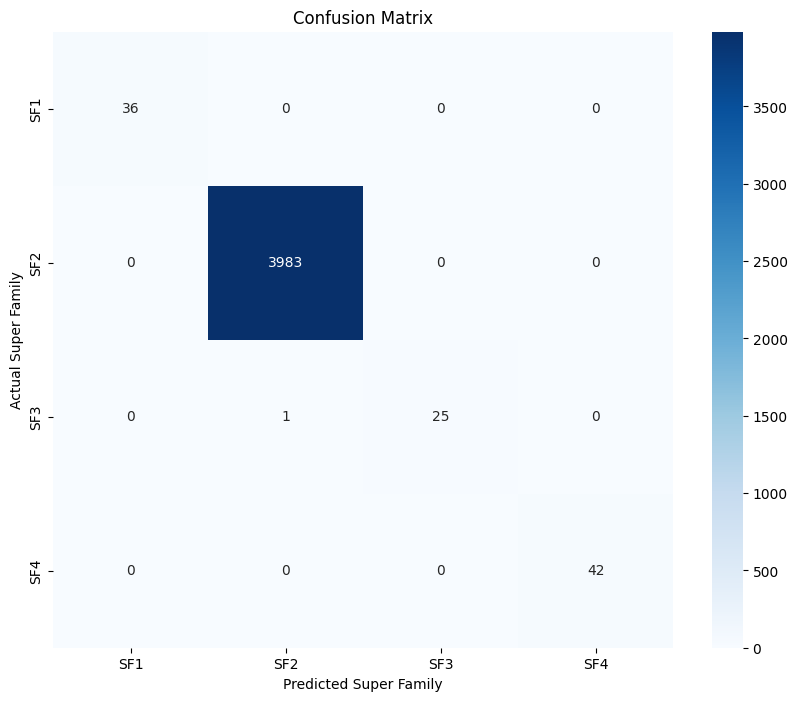

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get unique classes from the test set
classes = sorted(y_test.unique())

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Super Family')
plt.ylabel('Actual Super Family')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the confusion matrix plot as a PNG file
plt.savefig('confusion_matrix.png')
print("Confusion matrix plot saved as 'confusion_matrix.png'. You can download it from the files tab.")

Confusion matrix plot saved as 'confusion_matrix.png'. You can download it from the files tab.


<Figure size 640x480 with 0 Axes>